In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/tanzania.csv")
df["Country"] = "Tanzania"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df.duplicated().sum()
df = df.drop_duplicates()
df.describe()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,22.634596,29.472644,16.895906,12.576738,2.565570,67.652790,3.082678,4.406368,89.304265,12.330949,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,14.550000,21.220000,8.730000,3.140000,0.000000,38.510000,0.500000,0.840000,88.800000,5.980000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,21.240000,27.280000,15.347500,10.240000,0.000000,57.967500,2.247500,3.500000,89.150000,10.350000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,22.500000,29.140000,17.390000,13.110000,0.110000,67.020000,3.190000,4.580000,89.270000,12.190000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,24.030000,31.712500,18.560000,15.090000,1.522500,78.130000,3.940000,5.370000,89.460000,14.470000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.100000,37.050000,23.360000,19.680000,181.220000,93.680000,5.730000,7.950000,89.870000,17.160000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,2.074379,2.906126,2.180845,3.169672,7.900667,11.929111,1.110223,1.278884,0.200611,2.336082,NaN,3.477046


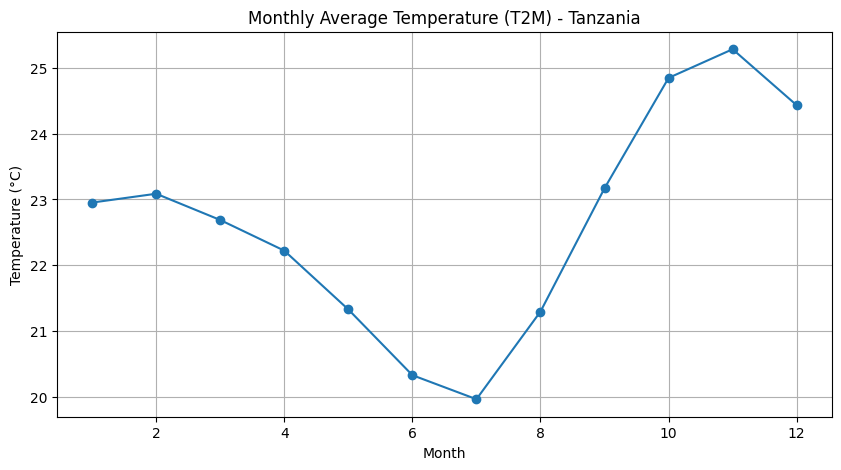

In [110]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Tanzania")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [111]:
df.isna().sum()


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [112]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [113]:
high_missing = missing_pct[missing_pct > 5]
high_missing


Series([], dtype: float64)

In [114]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
z_scores.head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-0.686841,-1.752596,0.845690,7.099560,1.443469,-2.182420,-2.499645
1,0.123138,-0.114477,-0.076083,-0.301982,0.459202,-1.840105,-1.788001
2,0.065282,-0.510241,0.960339,-0.164002,0.479324,-0.948283,-0.591500
3,0.050819,-0.475827,0.524675,1.148705,1.064518,-1.416715,-1.678517
4,-0.628986,-1.542669,0.859448,6.964112,1.539046,-1.290599,-1.107638


In [115]:
df = df[df.isna().mean(axis=1) <= 0.3]
df = df.sort_values("DATE")
df = df.ffill()

In [116]:
df.to_csv("../data/Tanzania_clean.csv", index=False)

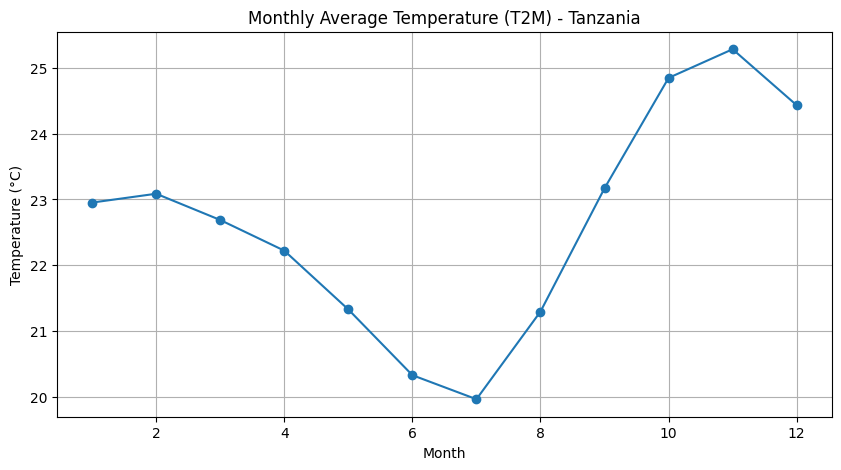

In [117]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Tanzania")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [118]:
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_month, coolest_month

(np.int32(11), np.int32(7))

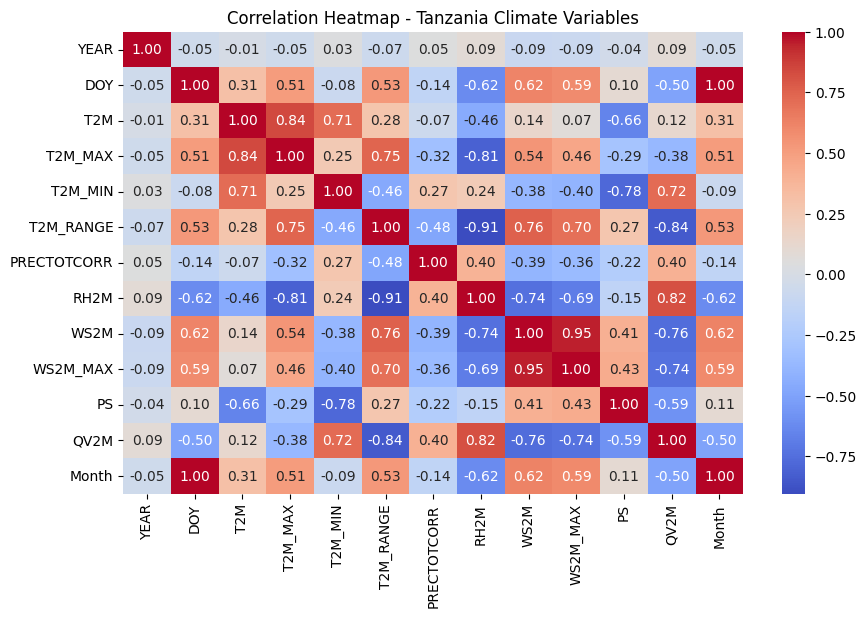

In [119]:
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Tanzania Climate Variables")
plt.show()

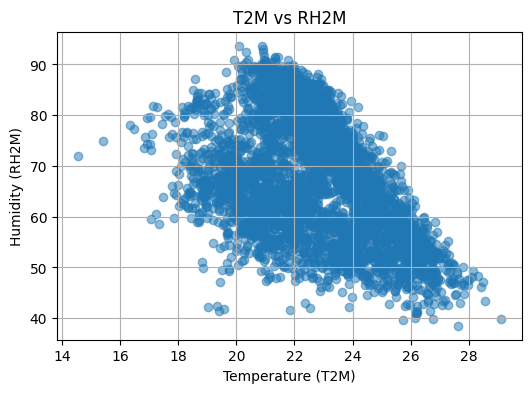

In [120]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.grid(True)
plt.show()

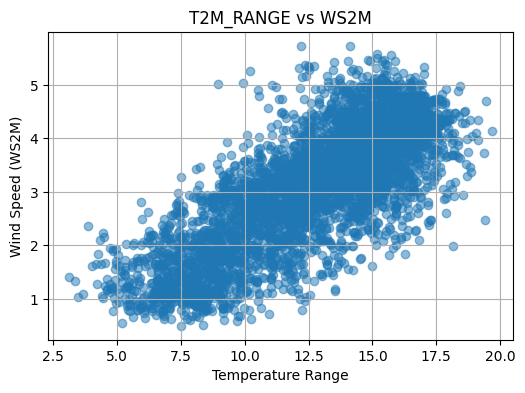

In [121]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True)
plt.show()

In [122]:
corr_unstack = corr.unstack().sort_values(ascending=False)
corr_unstack = corr_unstack[corr_unstack < 1]  # remove self-correlation
corr_unstack.head(3)

DOY       Month    0.996557
Month     DOY      0.996557
WS2M_MAX  WS2M     0.953343
dtype: float64

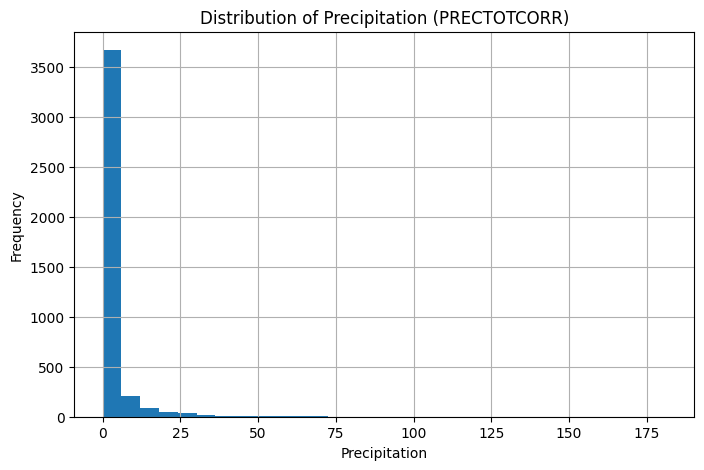

In [123]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30)
plt.title("Distribution of Precipitation (PRECTOTCORR)")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

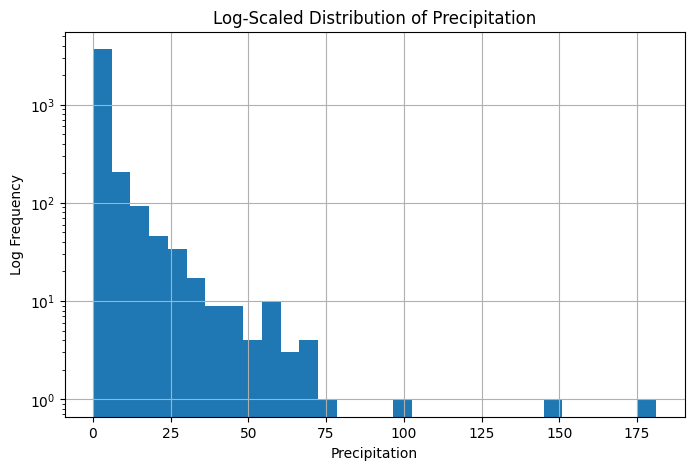

In [124]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30, log=True)
plt.title("Log-Scaled Distribution of Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Log Frequency")
plt.grid(True)
plt.show()

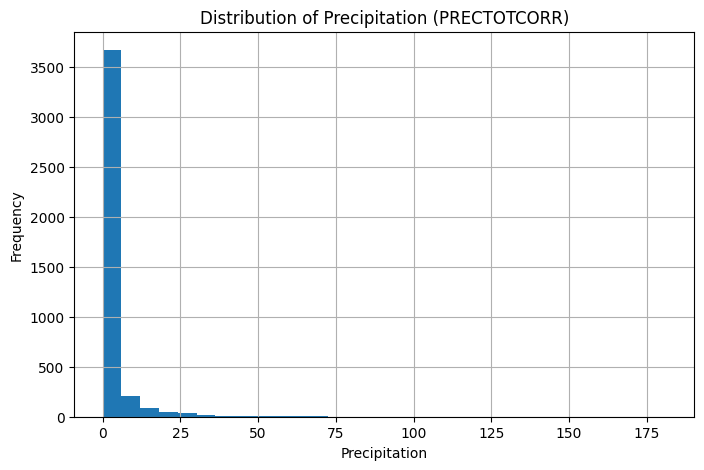

In [125]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30)
plt.title("Distribution of Precipitation (PRECTOTCORR)")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

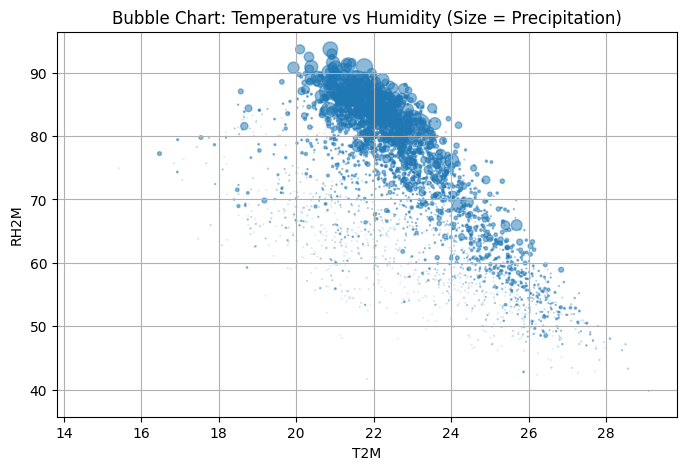

In [126]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.title("Bubble Chart: Temperature vs Humidity (Size = Precipitation)")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.grid(True)
plt.show()